In [136]:
import pandas as pd

In [137]:
df = pd.read_csv(r'merged_predictions.csv')
df.columns

Index(['source_date', 'obs_date', 'raw_filename', 'noaa_ar_filename_res',
       'local_request_date', 'error_res', 'flare_probability_res',
       'non_flare_probability_res', 'explanation_res', 'distances_res',
       'score_res', 'ratio_res', 'actual_res', 'score_f_res', 'ratio_f_res',
       'year', 'month', 'day', 'noaa_ar_filename_alex', 'error_alex',
       'flare_probability_alex', 'non_flare_probability_alex',
       'explanation_alex', 'distances_alex', 'score_alex', 'ratio_alex',
       'actual_alex', 'score_f_alex', 'ratio_f_alex'],
      dtype='object')

In [138]:
# Function to calculate weighted arithmetic mean for a single entry
def weighted_arithmetic_mean(entry):
    # Parse the string entry to a dictionary
    entry_dict = eval(entry)
    
    # Extract distances
    distances = entry_dict['Distance']
    
    # Calculate weighted mean
    weighted_mean = (sum([d * d for d in distances]) / sum(distances)) if sum(distances) != 0 else 0
    
    return weighted_mean

# Apply the function to the 'metrics' column
df['score_res'] = df['distances_res'].apply(weighted_arithmetic_mean)
df['score_alex'] = df['distances_alex'].apply(weighted_arithmetic_mean)

In [139]:
threshold = 0.5
df['predicted_alex'] = df['flare_probability_alex'].apply(lambda x: 1 if x >= threshold else 0)
df['predicted_res'] = df['flare_probability_res'].apply(lambda x: 1 if x >= threshold else 0)

In [140]:
def classify(row, model):
    pred_col = f'predicted_{model}'
    actual_col = f'actual_{model}'
    if row[pred_col] == 1 and row[actual_col] == 1:
        return 'TP'
    elif row[pred_col] == 1 and row[actual_col] == 0:
        return 'FP'
    elif row[pred_col] == 0 and row[actual_col] == 1:
        return 'FN'
    elif row[pred_col] == 0 and row[actual_col] == 0:
        return 'TN'

df['classification_alex'] = df.apply(lambda row: classify(row, 'alex'), axis=1)
df['classification_res'] = df.apply(lambda row: classify(row, 'res'), axis=1)

In [141]:
def calculate_metrics(df, model):
    class_col = f'classification_{model}'
    
    # Calculate TP, FP, FN, and TN
    TP = len(df[(df[class_col] == 'TP')])
    FP = len(df[(df[class_col] == 'FP')])
    FN = len(df[(df[class_col] == 'FN')])
    TN = len(df[(df[class_col] == 'TN')])
    
    # Calculate metrics
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    balanced_accuracy = 0.5 * (TP / (TP + FN) + TN / (TN + FP)) if (TP + FN) > 0 and (TN + FP) > 0 else 0
    tss = recall - (FP / (FP + TN)) if (FP + TN) > 0 else 0
    hss = (2 * (TP * TN - FP * FN)) / ((TP + FN) * (FN + TN) + (TP + FP) * (FP + TN)) if (TP + FN) > 0 and (FN + TN) > 0 and (TP + FP) > 0 and (FP + TN) > 0 else 0
    accuracy_positive_class = TP / (TP + FN) if (TP + FN) > 0 else 0
    accuracy_negative_class = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return {
        'Model': model,
        'Balanced Accuracy': balanced_accuracy,
        'Precision': precision,
        'Recall': recall,
        'TSS': tss,
        'HSS': hss,
        'Accuracy Positive Class': accuracy_positive_class,
        'Accuracy Negative Class': accuracy_negative_class
    }

# List of models
models = ['res', 'alex']

# Calculate metrics for each model and store in a list
metrics = [calculate_metrics(df, model) for model in models]

# Convert list of metrics to DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Balanced Accuracy,Precision,Recall,TSS,HSS,Accuracy Positive Class,Accuracy Negative Class
0,res,0.587080,0.579832,0.201754,0.174161,0.236789,0.201754,0.972406
1,alex,0.749008,0.433781,0.660819,0.498015,0.410801,0.660819,0.837196


### Exploratory Data Analysis

In [142]:
df.groupby('classification_alex')['ratio_alex'].describe()
# df.groupby('classification_alex')['score_alex'].describe()

,count,mean,std,min,25%,50%,75%,max
classification_alex,,,,,,,,
FN,116.0,0.514138,0.311197,0.0,0.33,0.5,0.75,1.0
FP,295.0,0.511085,0.288515,0.0,0.29,0.5,0.75,1.0
TN,1517.0,0.560850,0.304573,0.0,0.33,0.5,0.75,1.0
TP,226.0,0.574425,0.305521,0.0,0.33,0.5,0.83,1.0


In [143]:
df.groupby('classification_res')['ratio_res'].describe()
# df.groupby('classification_res')['score_res'].describe()

,count,mean,std,min,25%,50%,75%,max
classification_res,,,,,,,,
FN,273.0,0.521355,0.309948,0.0,0.33,0.5,0.7500,1.0
FP,50.0,0.446200,0.272808,0.0,0.25,0.5,0.5000,1.0
TN,1762.0,0.561294,0.327723,0.0,0.33,0.5,0.8225,1.0
TP,69.0,0.462754,0.342271,0.0,0.20,0.4,0.6700,1.0


#### Boxplot - Classifications

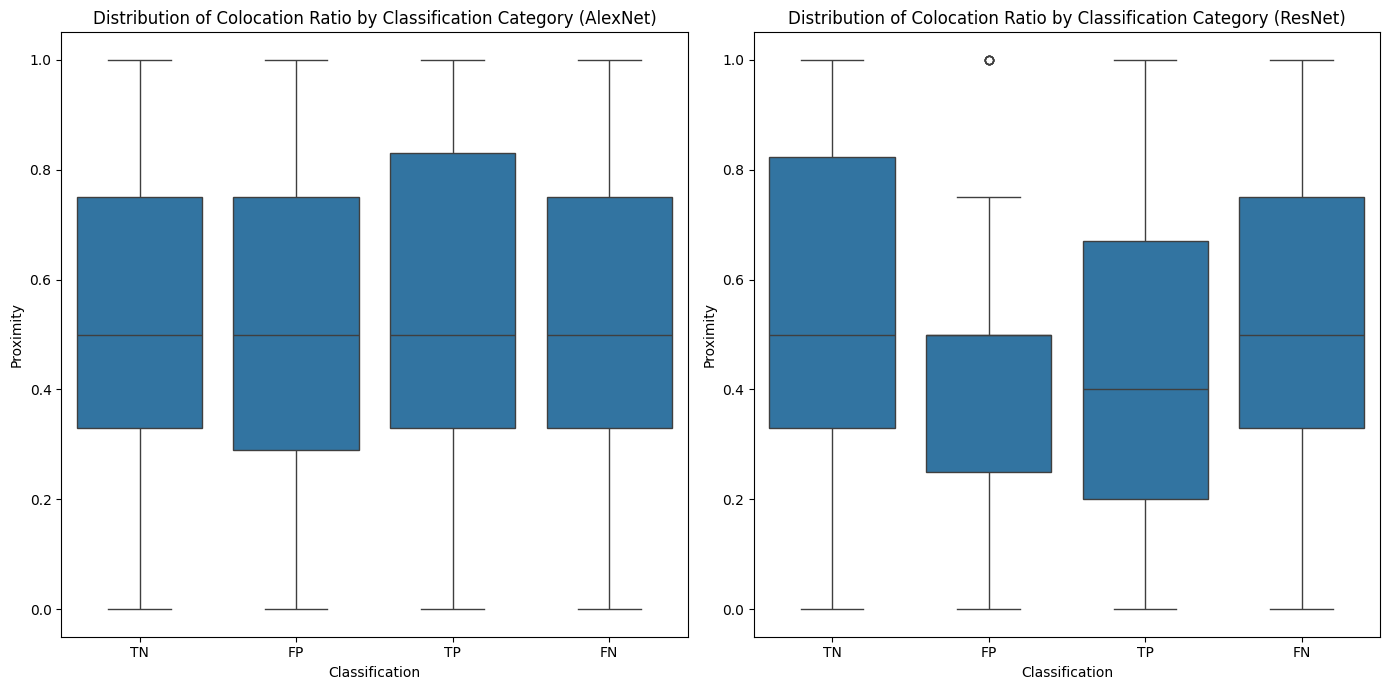

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the order of the categories
order = ['TN', 'FP', 'TP', 'FN']

# Create a figure with subplots for each model
plt.figure(figsize=(14, 7))

# Box plot for AlexNet
plt.subplot(1, 2, 1)
sns.boxplot(x='classification_alex', y='ratio_alex', data=df, order=order)
plt.title('Distribution of Colocation Ratio by Classification Category (AlexNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Box plot for ResNet
plt.subplot(1, 2, 2)
sns.boxplot(x='classification_res', y='ratio_res', data=df, order=order)
plt.title('Distribution of Colocation Ratio by Classification Category (ResNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()


plt.savefig('imgs/colocation_ratio_boxplot.png', dpi=300, bbox_inches='tight', pad_inches=0)
# Show the plot
plt.show()

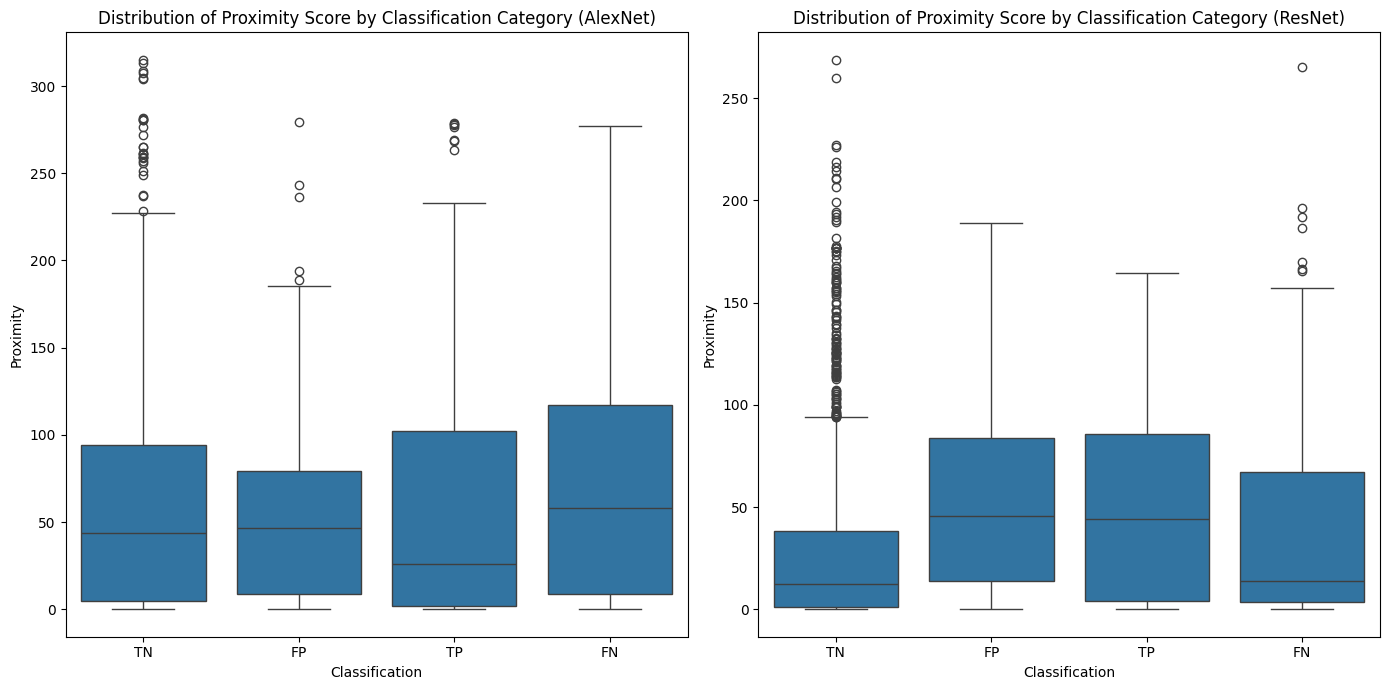

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the order of the categories
order = ['TN', 'FP', 'TP', 'FN']

# Create a figure with subplots for each model
plt.figure(figsize=(14, 7))

# Box plot for AlexNet
plt.subplot(1, 2, 1)
sns.boxplot(x='classification_alex', y='score_alex', data=df, order=order)
plt.title('Distribution of Proximity Score by Classification Category (AlexNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Box plot for ResNet
plt.subplot(1, 2, 2)
sns.boxplot(x='classification_res', y='score_res', data=df, order=order)
plt.title('Distribution of Proximity Score by Classification Category (ResNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

# Show the plot
plt.savefig('imgs/proximity_score_boxplot.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


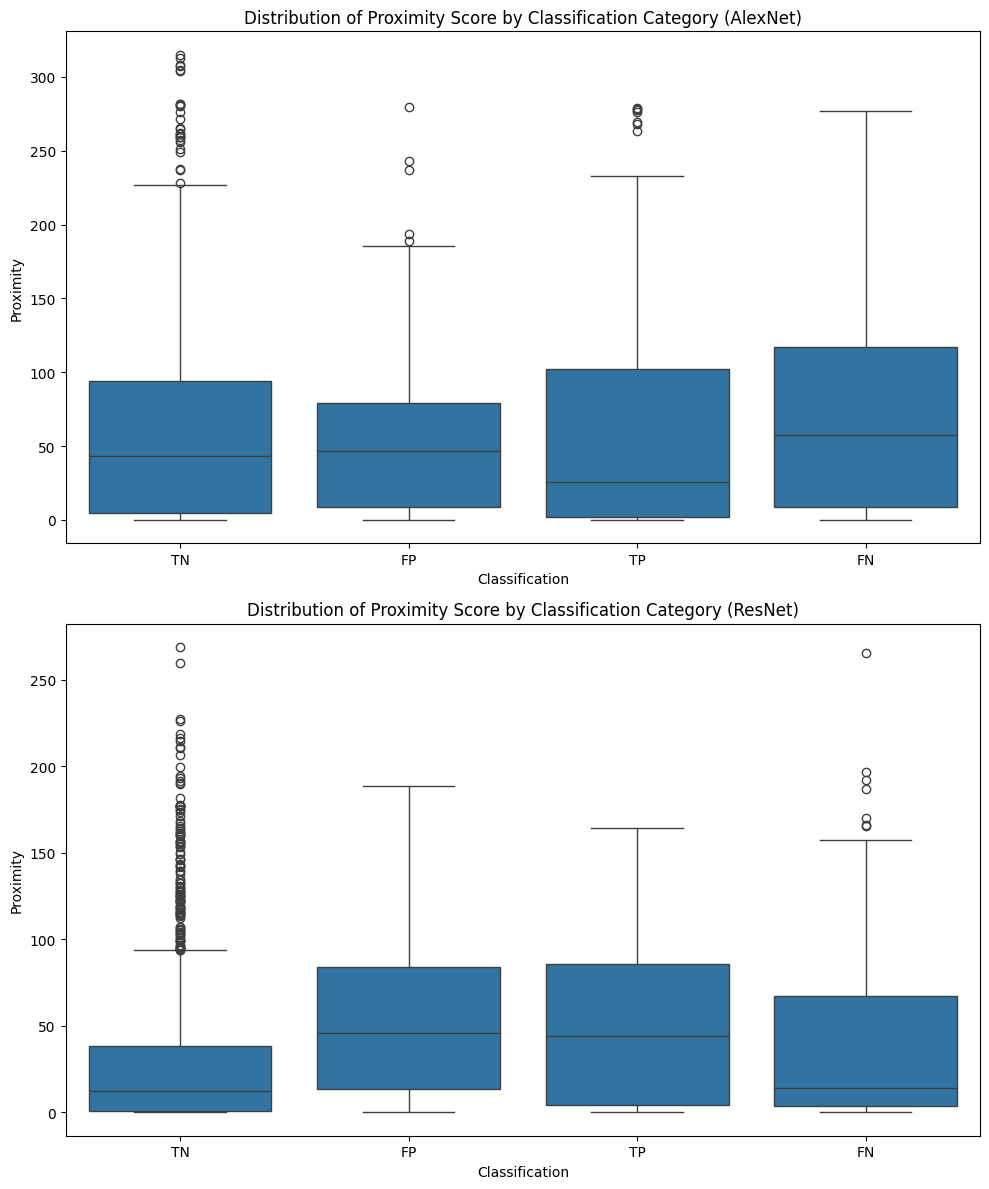

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the order of the categories
order = ['TN', 'FP', 'TP', 'FN']

# Create a figure with subplots for each model
plt.figure(figsize=(10, 12))

# Box plot for AlexNet
plt.subplot(2, 1, 1)
sns.boxplot(x='classification_alex', y='score_alex', data=df, order=order)
plt.title('Distribution of Proximity Score by Classification Category (AlexNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Box plot for ResNet
plt.subplot(2, 1, 2)
sns.boxplot(x='classification_res', y='score_res', data=df, order=order)
plt.title('Distribution of Proximity Score by Classification Category (ResNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

# Show the plot
plt.savefig('imgs/proximity_score_boxplot.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


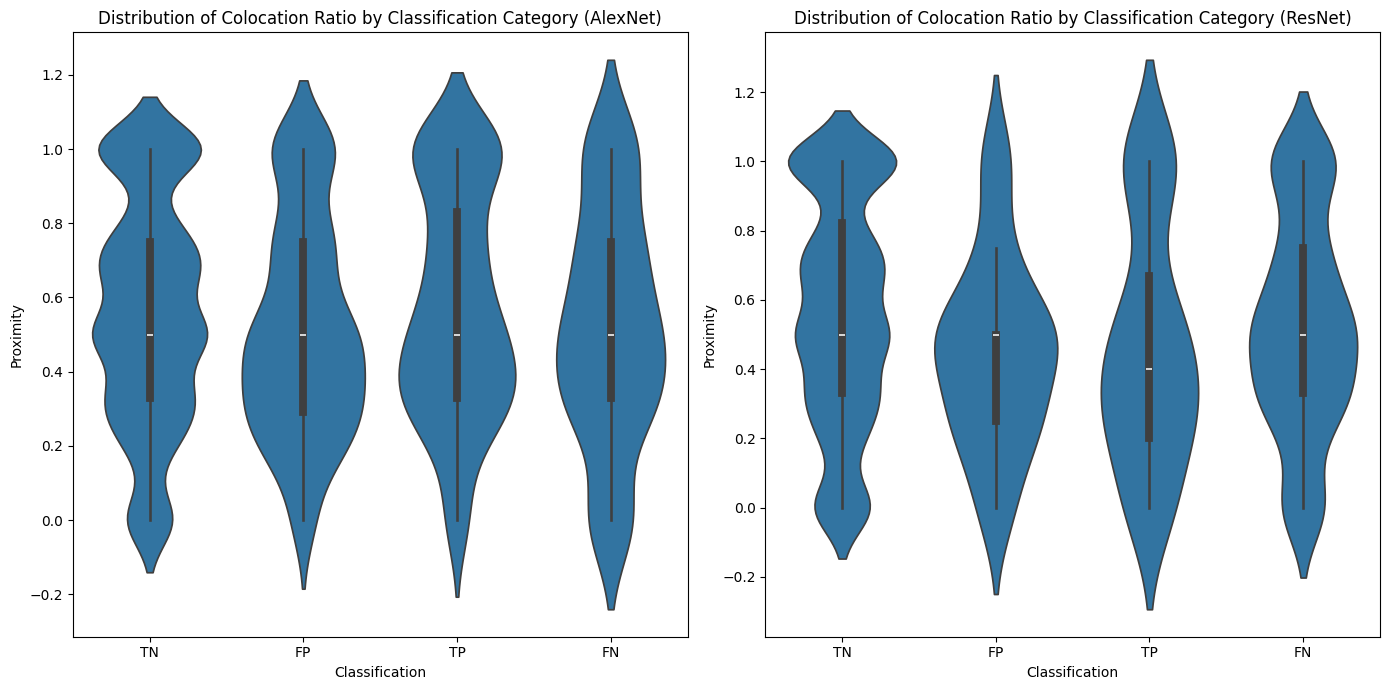

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the order of the categories
order = ['TN', 'FP', 'TP', 'FN']

# Create a figure with subplots for each model
plt.figure(figsize=(14, 7))

# Violin plot for AlexNet
plt.subplot(1, 2, 1)
sns.violinplot(x='classification_alex', y='ratio_alex', data=df, order=order)
plt.title('Distribution of Colocation Ratio by Classification Category (AlexNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Violin plot for ResNet
plt.subplot(1, 2, 2)
sns.violinplot(x='classification_res', y='ratio_res', data=df, order=order)
plt.title('Distribution of Colocation Ratio by Classification Category (ResNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

plt.savefig('imgs/colocation_ratio_violin.png', dpi=300, bbox_inches='tight', pad_inches=0)

# Show the plot
plt.show()


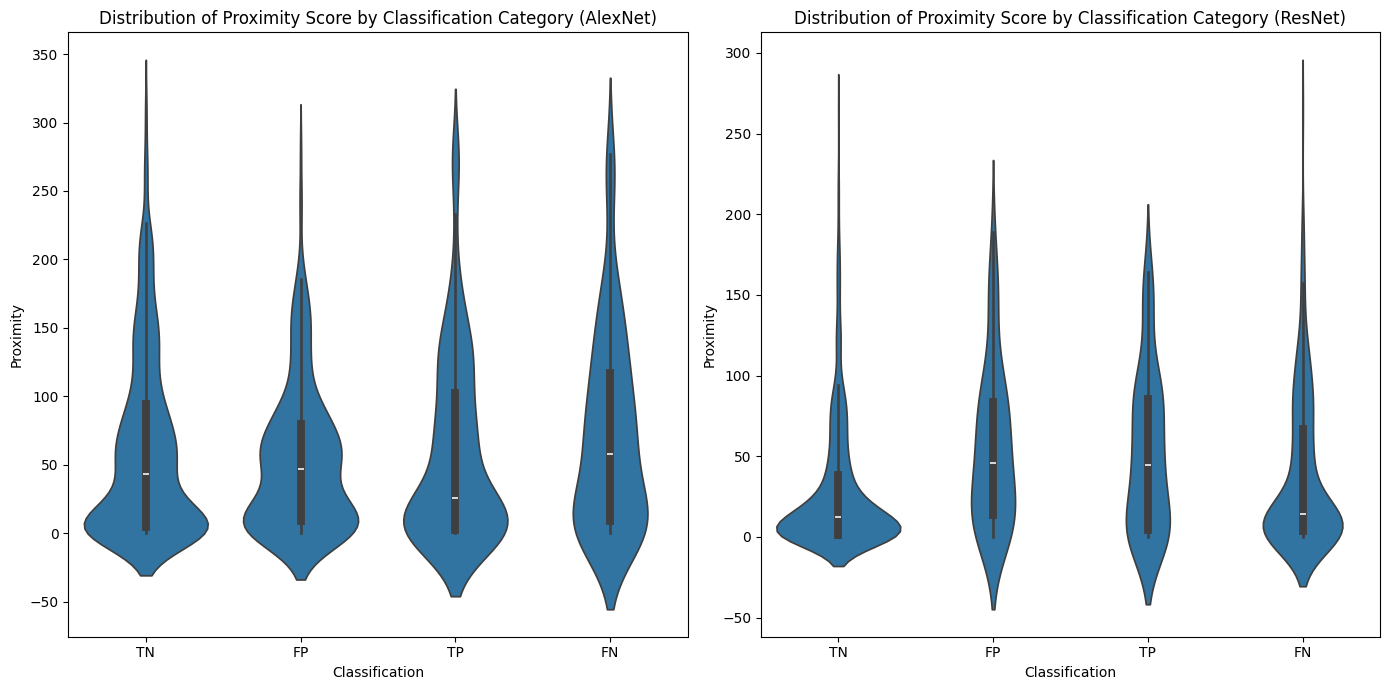

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the order of the categories
order = ['TN', 'FP', 'TP', 'FN']

# Create a figure with subplots for each model
plt.figure(figsize=(14, 7))

# Violin plot for AlexNet
plt.subplot(1, 2, 1)
sns.violinplot(x='classification_alex', y='score_alex', data=df, order=order)
plt.title('Distribution of Proximity Score by Classification Category (AlexNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Violin plot for ResNet
plt.subplot(1, 2, 2)
sns.violinplot(x='classification_res', y='score_res', data=df, order=order)
plt.title('Distribution of Proximity Score by Classification Category (ResNet)')
plt.xlabel('Classification')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

plt.savefig('imgs/proximity_score_violin.png', dpi=300, bbox_inches='tight', pad_inches=0)

# Show the plot
plt.show()


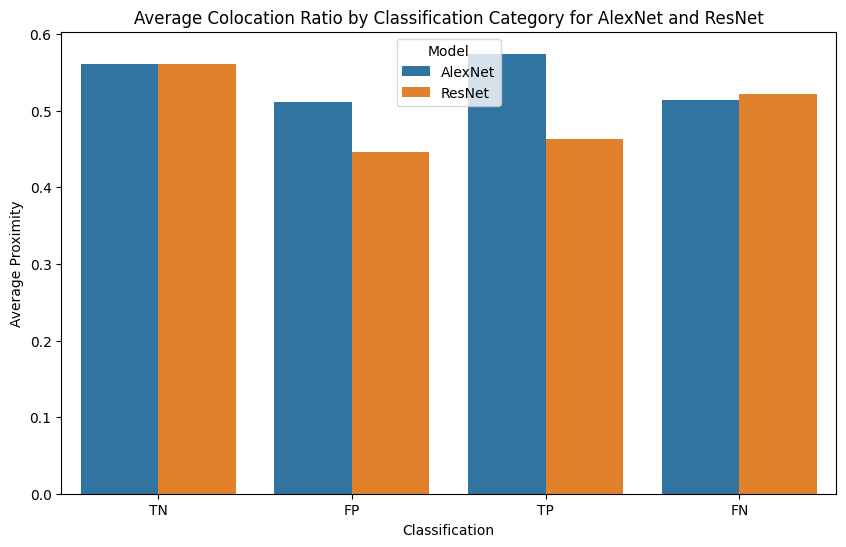

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a new DataFrame to hold average values
average_df = pd.DataFrame({
    'Classification': ['TN', 'FP', 'TP', 'FN'],
    'AlexNet': [
        df[df['classification_alex'] == 'TN']['ratio_alex'].mean(),
        df[df['classification_alex'] == 'FP']['ratio_alex'].mean(),
        df[df['classification_alex'] == 'TP']['ratio_alex'].mean(),
        df[df['classification_alex'] == 'FN']['ratio_alex'].mean()
    ],
    'ResNet': [
        df[df['classification_res'] == 'TN']['ratio_res'].mean(),
        df[df['classification_res'] == 'FP']['ratio_res'].mean(),
        df[df['classification_res'] == 'TP']['ratio_res'].mean(),
        df[df['classification_res'] == 'FN']['ratio_res'].mean()
    ]
})

# Melt the DataFrame for easy plotting
average_df_melted = pd.melt(average_df, id_vars='Classification', value_vars=['AlexNet', 'ResNet'], var_name='Model', value_name='Average Proximity')

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Classification', y='Average Proximity', hue='Model', data=average_df_melted)
plt.title('Average Colocation Ratio by Classification Category for AlexNet and ResNet')
plt.xlabel('Classification')
plt.ylabel('Average Proximity')
plt.legend(title='Model')

plt.savefig('imgs/colocation_ratio_mean.png', dpi=300, bbox_inches='tight', pad_inches=0)

# Show the plot
plt.show()


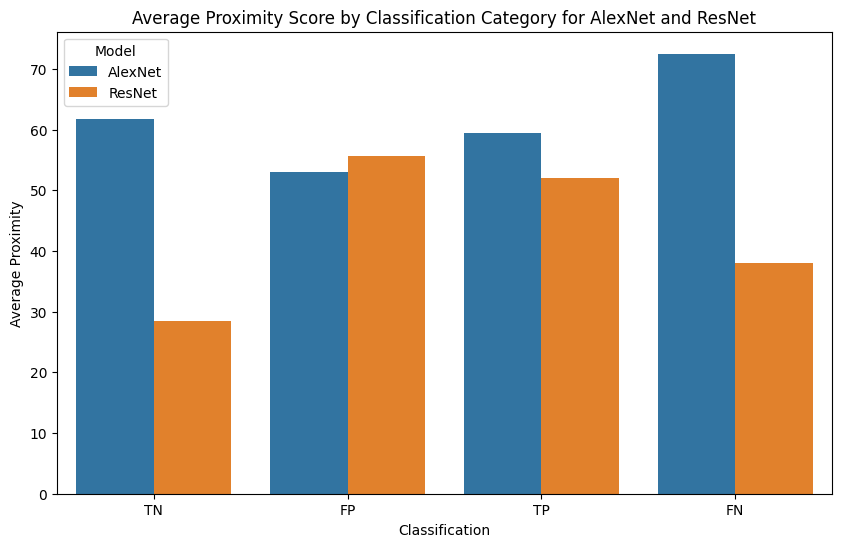

In [165]:
# Create a new DataFrame to hold average values
average_df = pd.DataFrame({
    'Classification': ['TN', 'FP', 'TP', 'FN'],
    'AlexNet': [
        df[df['classification_alex'] == 'TN']['score_alex'].mean(),
        df[df['classification_alex'] == 'FP']['score_alex'].mean(),
        df[df['classification_alex'] == 'TP']['score_alex'].mean(),
        df[df['classification_alex'] == 'FN']['score_alex'].mean()
    ],
    'ResNet': [
        df[df['classification_res'] == 'TN']['score_res'].mean(),
        df[df['classification_res'] == 'FP']['score_res'].mean(),
        df[df['classification_res'] == 'TP']['score_res'].mean(),
        df[df['classification_res'] == 'FN']['score_res'].mean()
    ]
})

# Melt the DataFrame for easy plotting
average_df_melted = pd.melt(average_df, id_vars='Classification', value_vars=['AlexNet', 'ResNet'], var_name='Model', value_name='Average Proximity')

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Classification', y='Average Proximity', hue='Model', data=average_df_melted)
plt.title('Average Proximity Score by Classification Category for AlexNet and ResNet')
plt.xlabel('Classification')
plt.ylabel('Average Proximity')
plt.legend(title='Model')


plt.savefig('imgs/proximity_score_mean.png', dpi=300, bbox_inches='tight', pad_inches=0)

# Show the plot
plt.show()


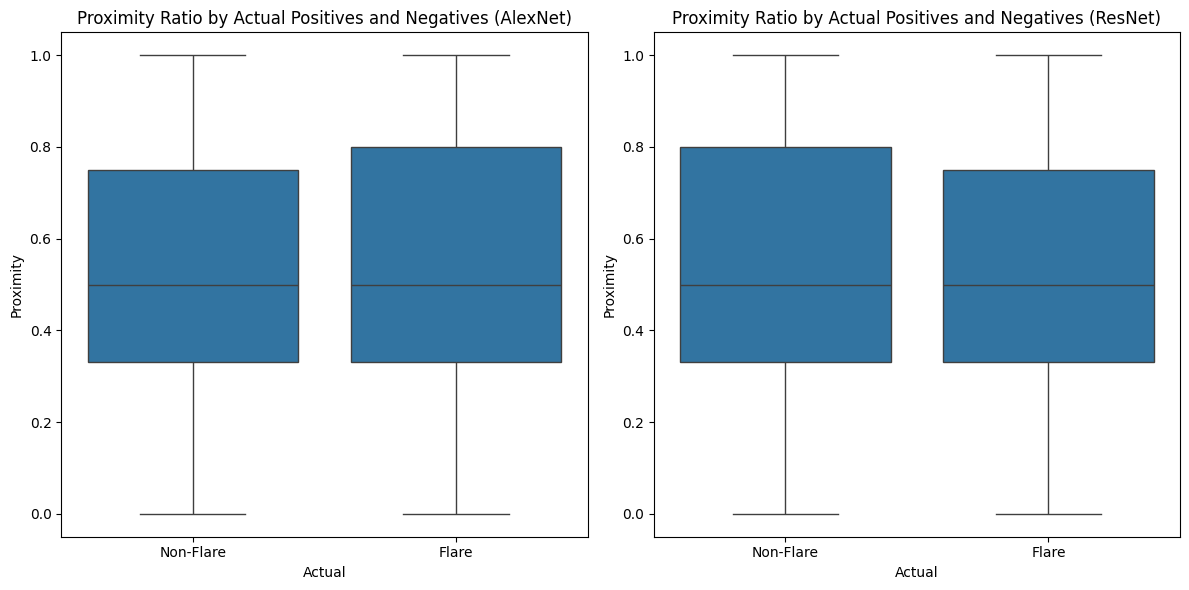

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter DataFrame for actual positives and negatives
df['actual_desc_alex'] = df['actual_alex'].apply(lambda x: 'Flare' if x == 1 else 'Non-Flare')
df['actual_desc_res'] = df['actual_res'].apply(lambda x: 'Flare' if x == 1 else 'Non-Flare')

# Create a box plot for AlexNet
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Create a subplot for AlexNet
sns.boxplot(x='actual_desc_alex', y='ratio_alex', data=df)
plt.title('Proximity Ratio by Actual Positives and Negatives (AlexNet)')
plt.xlabel('Actual')
plt.ylabel('Proximity')

# Create a box plot for ResNet
plt.subplot(1, 2, 2)  # Create a subplot for ResNet
sns.boxplot(x='actual_desc_res', y='ratio_res', data=df)
plt.title('Proximity Ratio by Actual Positives and Negatives (ResNet)')
plt.xlabel('Actual')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

# Show the plot
plt.show()


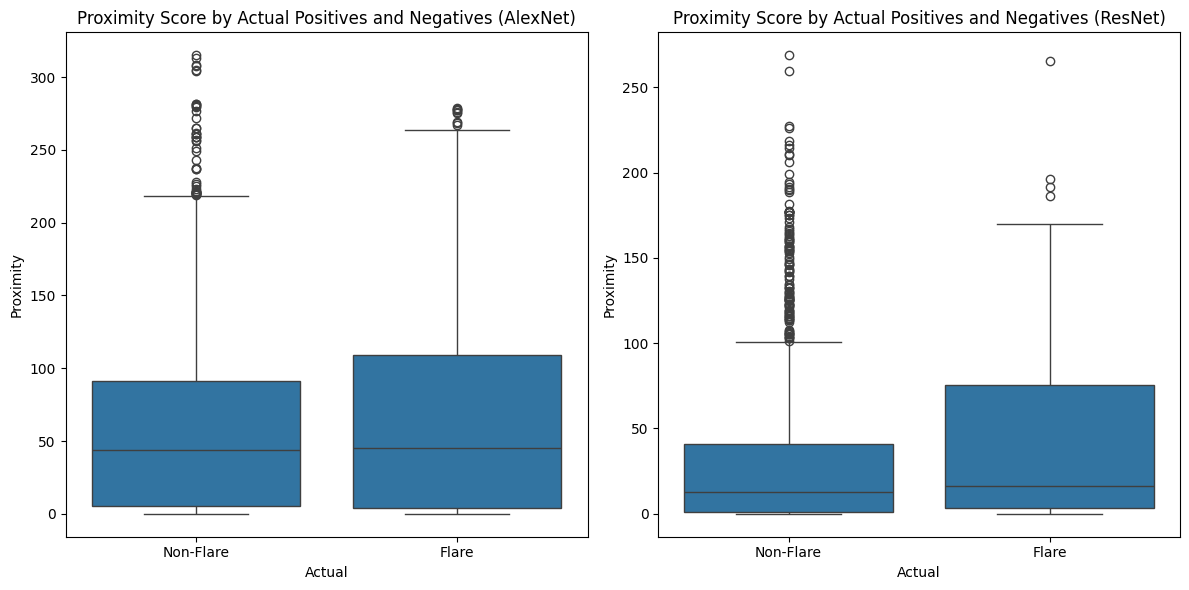

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter DataFrame for actual positives and negatives
df['actual_desc_alex'] = df['actual_alex'].apply(lambda x: 'Flare' if x == 1 else 'Non-Flare')
df['actual_desc_res'] = df['actual_res'].apply(lambda x: 'Flare' if x == 1 else 'Non-Flare')

# Create a box plot for AlexNet
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Create a subplot for AlexNet
sns.boxplot(x='actual_desc_alex', y='score_alex', data=df)
plt.title('Proximity Score by Actual Positives and Negatives (AlexNet)')
plt.xlabel('Actual')
plt.ylabel('Proximity')

# Create a box plot for ResNet
plt.subplot(1, 2, 2)  # Create a subplot for ResNet
sns.boxplot(x='actual_desc_res', y='score_res', data=df)
plt.title('Proximity Score by Actual Positives and Negatives (ResNet)')
plt.xlabel('Actual')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

# Show the plot
plt.show()


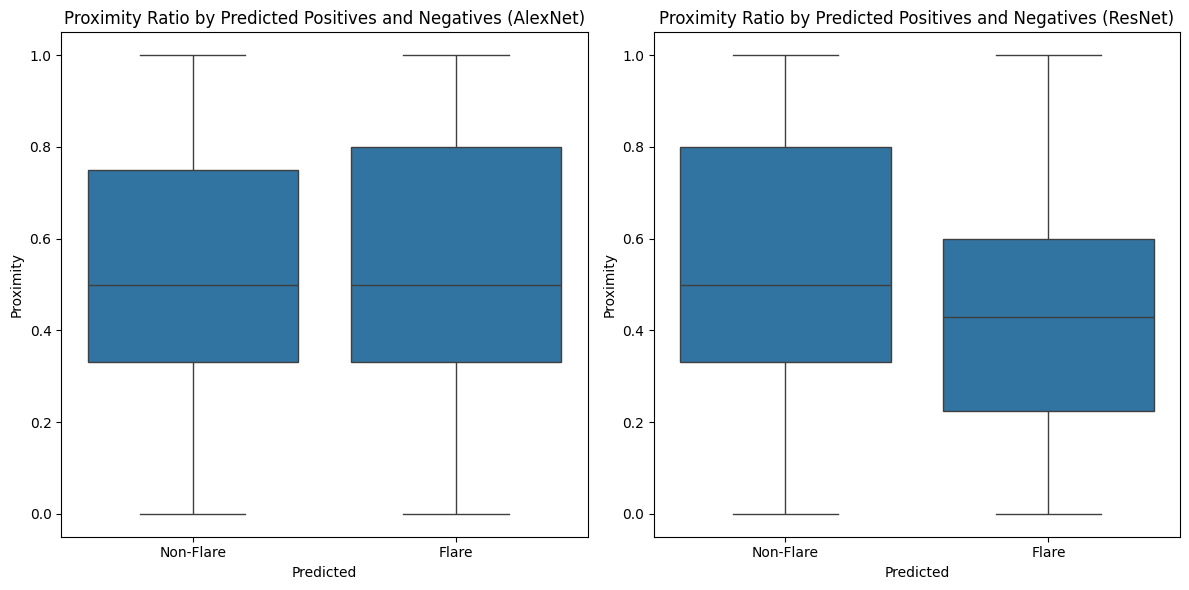

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter DataFrame for actual positives and negatives
df['predicted_desc_alex'] = df['predicted_alex'].apply(lambda x: 'Flare' if x == 1 else 'Non-Flare')
df['predicted_desc_res'] = df['predicted_res'].apply(lambda x: 'Flare' if x == 1 else 'Non-Flare')

# Create a box plot for AlexNet
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Create a subplot for AlexNet
sns.boxplot(x='predicted_desc_alex', y='ratio_alex', data=df)
plt.title('Proximity Ratio by Predicted Positives and Negatives (AlexNet)')
plt.xlabel('Predicted')
plt.ylabel('Proximity')

# Create a box plot for ResNet
plt.subplot(1, 2, 2)  # Create a subplot for ResNet
sns.boxplot(x='predicted_desc_res', y='ratio_res', data=df)
plt.title('Proximity Ratio by Predicted Positives and Negatives (ResNet)')
plt.xlabel('Predicted')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

# Show the plot
plt.show()


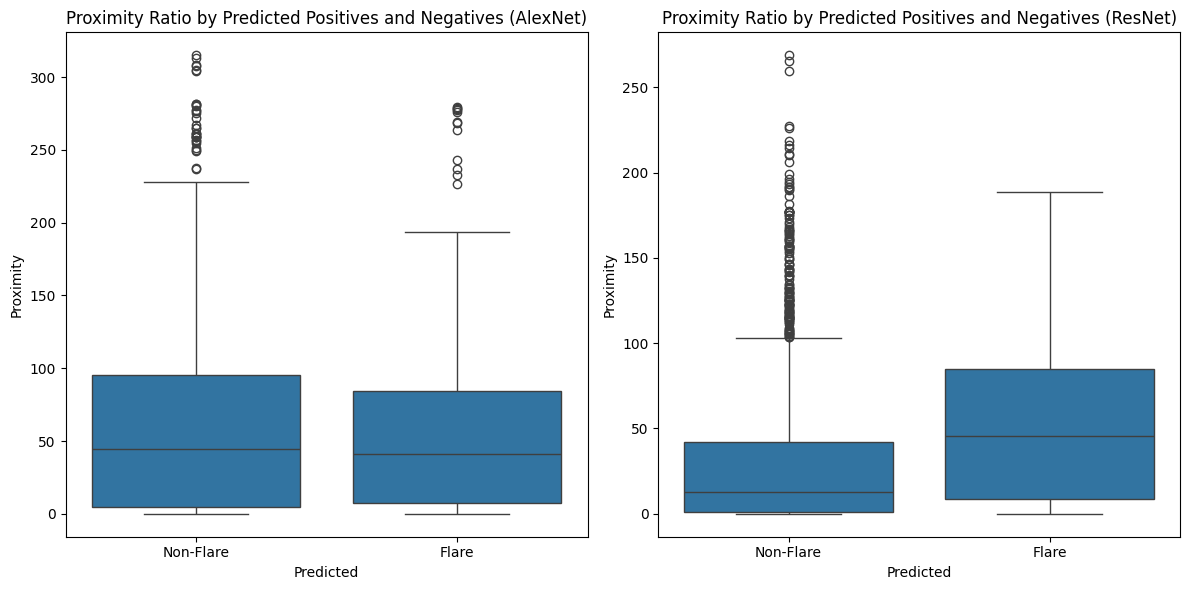

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter DataFrame for actual positives and negatives
df['predicted_desc_alex'] = df['predicted_alex'].apply(lambda x: 'Flare' if x == 1 else 'Non-Flare')
df['predicted_desc_res'] = df['predicted_res'].apply(lambda x: 'Flare' if x == 1 else 'Non-Flare')

# Create a box plot for AlexNet
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Create a subplot for AlexNet
sns.boxplot(x='predicted_desc_alex', y='score_alex', data=df)
plt.title('Proximity Score by Predicted Positives and Negatives (AlexNet)')
plt.xlabel('Predicted')
plt.ylabel('Proximity')

# Create a box plot for ResNet
plt.subplot(1, 2, 2)  # Create a subplot for ResNet
sns.boxplot(x='predicted_desc_res', y='score_res', data=df)
plt.title('Proximity Score by Predicted Positives and Negatives (ResNet)')
plt.xlabel('Predicted')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

# Show the plot
plt.show()


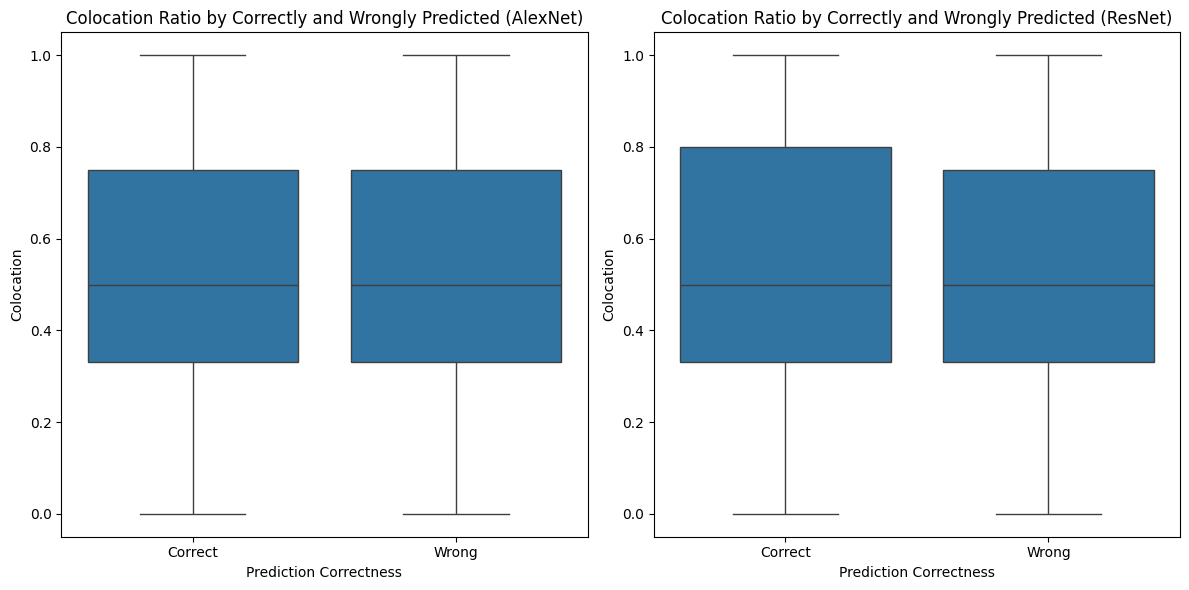

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define correctness based on classification
df['correctly_predicted_alex'] = df['classification_alex'].apply(lambda x: 'Correct' if x in ['TP', 'TN'] else 'Wrong')
df['correctly_predicted_res'] = df['classification_res'].apply(lambda x: 'Correct' if x in ['TP', 'TN'] else 'Wrong')

# Create a box plot for AlexNet
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Create a subplot for AlexNet
sns.boxplot(x='correctly_predicted_alex', y='ratio_alex', data=df)
plt.title('Colocation Ratio by Correctly and Wrongly Predicted (AlexNet)')
plt.xlabel('Prediction Correctness')
plt.ylabel('Colocation')

# Create a box plot for ResNet
plt.subplot(1, 2, 2)  # Create a subplot for ResNet
sns.boxplot(x='correctly_predicted_res', y='ratio_res', data=df)
plt.title('Colocation Ratio by Correctly and Wrongly Predicted (ResNet)')
plt.xlabel('Prediction Correctness')
plt.ylabel('Colocation')

# Adjust layout to make room for the titles
plt.tight_layout()

plt.savefig('imgs/colocation_correct.png', dpi=300, bbox_inches='tight', pad_inches=0)

# Show the plot
plt.show()


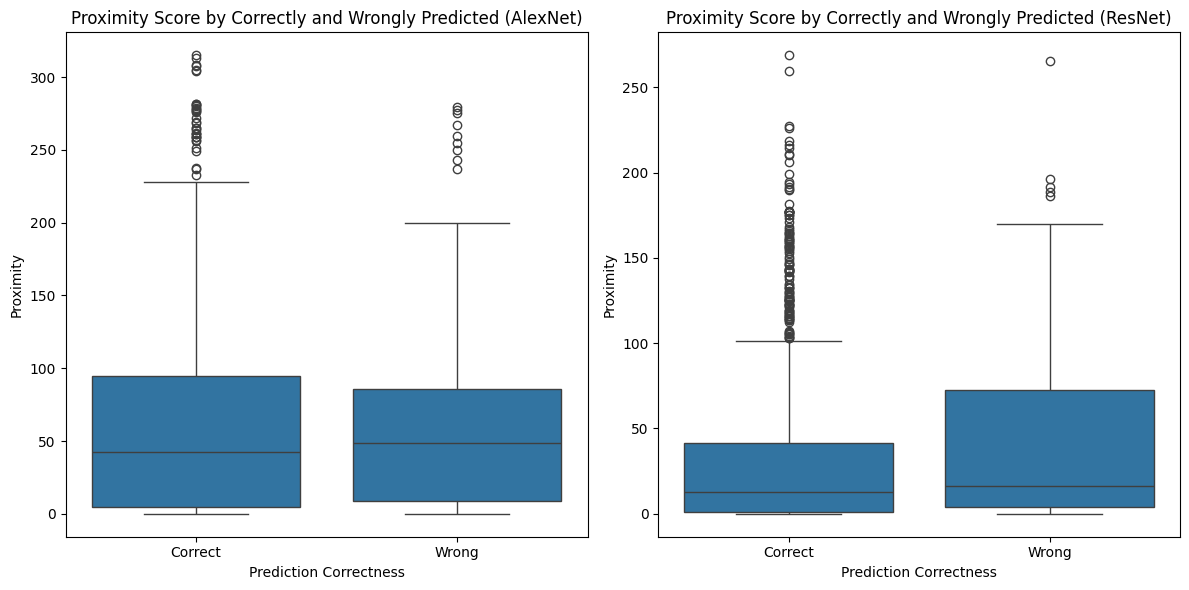

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define correctness based on classification
df['correctly_predicted_alex'] = df['classification_alex'].apply(lambda x: 'Correct' if x in ['TP', 'TN'] else 'Wrong')
df['correctly_predicted_res'] = df['classification_res'].apply(lambda x: 'Correct' if x in ['TP', 'TN'] else 'Wrong')

# Create a box plot for AlexNet
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Create a subplot for AlexNet
sns.boxplot(x='correctly_predicted_alex', y='score_alex', data=df)
plt.title('Proximity Score by Correctly and Wrongly Predicted (AlexNet)')
plt.xlabel('Prediction Correctness')
plt.ylabel('Proximity')

# Create a box plot for ResNet
plt.subplot(1, 2, 2)  # Create a subplot for ResNet
sns.boxplot(x='correctly_predicted_res', y='score_res', data=df)
plt.title('Proximity Score by Correctly and Wrongly Predicted (ResNet)')
plt.xlabel('Prediction Correctness')
plt.ylabel('Proximity')

# Adjust layout to make room for the titles
plt.tight_layout()

plt.savefig('imgs/proximity_correct.png', dpi=300, bbox_inches='tight', pad_inches=0)
# Show the plot
plt.show()


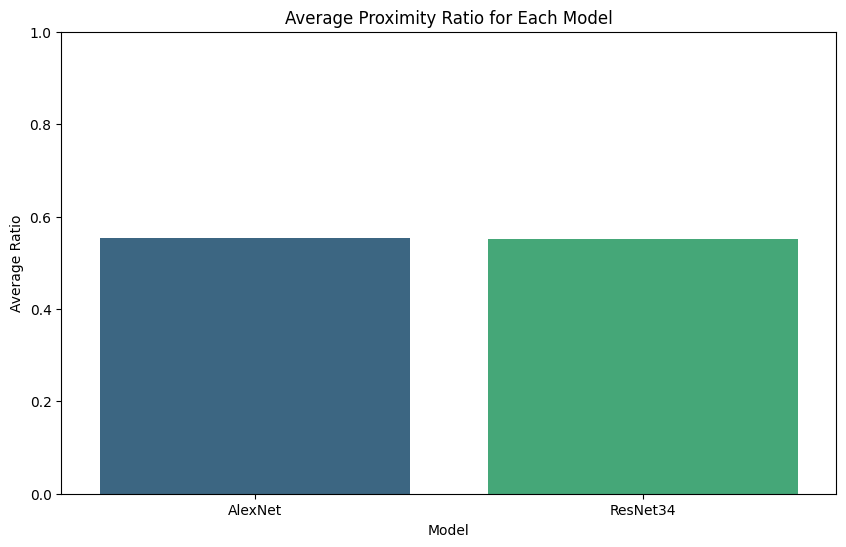

,Model,Average Ratio
0,AlexNet,0.552943
1,ResNet34,0.550404


In [168]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the average ratio for both models
average_ratios = {
    'Model': ['AlexNet', 'ResNet34'],
    'Average Ratio': [df['ratio_alex'].mean(), df['ratio_res'].mean()]
}

# Convert to DataFrame
average_ratios_df = pd.DataFrame(average_ratios)

# Plotting the average ratio for each model
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Average Ratio', data=average_ratios_df, palette='viridis', hue='Model', dodge=False)
plt.xlabel('Model')
plt.ylabel('Average Ratio')
plt.title('Average Proximity Ratio for Each Model')
plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.legend([],[], frameon=False)  # Hide the legend
plt.show()

average_ratios_df

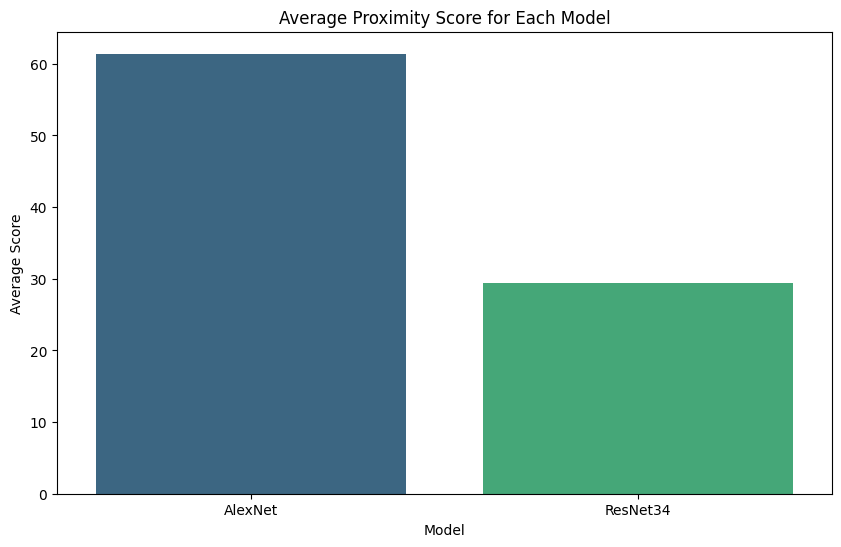

,Model,Average Score
0,AlexNet,61.405091
1,ResNet34,29.420010


In [169]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the average ratio for both models
average_ratios = {
    'Model': ['AlexNet', 'ResNet34'],
    'Average Score': [df[df.classification_alex.isin(['TP','TN'])]['score_alex'].mean(), df[df.classification_res.isin(['TP','TN'])]['score_res'].mean()]
}

# Convert to DataFrame
average_ratios_df = pd.DataFrame(average_ratios)

# Plotting the average ratio for each model
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Average Score', data=average_ratios_df, palette='viridis', hue='Model', dodge=False)
plt.xlabel('Model')
plt.ylabel('Average Score')
plt.title('Average Proximity Score for Each Model')

plt.show()


average_ratios_df

In [158]:
# # Function to calculate weighted arithmetic mean for a single entry
# def weighted_arithmetic_mean(entry):
#     # Parse the string entry to a dictionary
#     entry_dict = eval(entry)
    
#     # Extract distances
#     distances = entry_dict['Distance']
    
#     # Calculate weighted mean
#     weighted_mean = (sum([d * d for d in distances]) / sum(distances)) if sum(distances) != 0 else 0
    
#     return weighted_mean

# # Apply the function to the 'metrics' column
# df['weighted_score_res'] = df['distances_res'].apply(weighted_arithmetic_mean)
# df['weighted_score_alex'] = df['distances_alex'].apply(weighted_arithmetic_mean)

In [159]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd

# # Calculate the average ratio for both models
# average_ratios = {
#     'Model': ['AlexNet', 'ResNet34'],
#     'Average Score': [df[df.classification_alex.isin(['TP','TN'])]['weighted_score_alex'].mean(), df[df.classification_alex.isin(['TP','TN'])]['weighted_score_res'].mean()]
# }

# # Convert to DataFrame
# average_ratios_df = pd.DataFrame(average_ratios)

# # Plotting the average ratio for each model
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Model', y='Average Score', data=average_ratios_df, palette='viridis', hue='Model', dodge=False)
# plt.xlabel('Model')
# plt.ylabel('Average Score')
# plt.title('Average Proximity Score for Each Model')

# plt.show()

In [160]:
df[['flare_probability_res','score_res','ratio_res']]
df[['flare_probability_alex','score_alex','ratio_alex']]

,flare_probability_alex,score_alex,ratio_alex
0,0.314645,53.310412,0.75
1,0.335541,2.575927,0.75
2,0.589686,2.622096,0.50
3,0.607903,4.472136,0.75
4,0.859357,23.070207,0.50
...,...,...,...
2149,0.150792,187.076494,0.33
2150,0.268427,164.256389,0.33
2151,0.940105,57.579510,0.50
2152,0.291853,0.000000,1.00


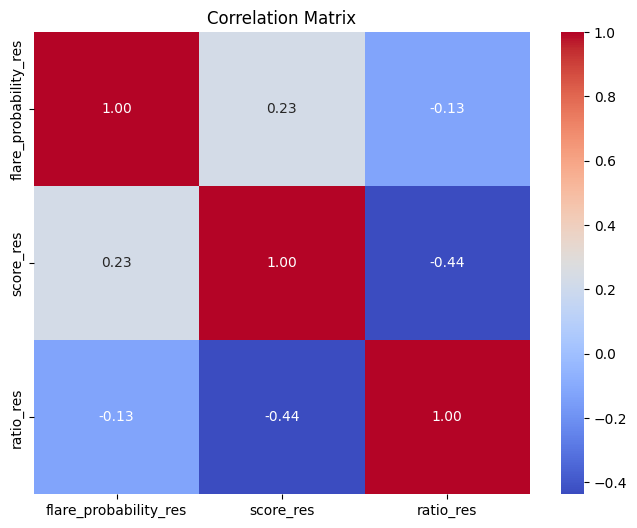

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a correlation matrix
correlation_matrix = df[['flare_probability_res','score_res','ratio_res']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
